# --------------------- PCA Using Sklearn ------------------------

### Importing loibraries

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/wehrley/Kaggle-Digit-Recognizer/master/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Printing Image from dataset

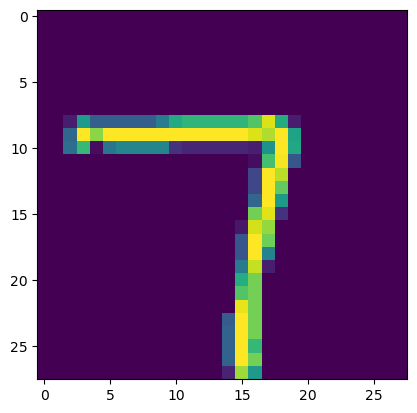

In [4]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[28352,1:].values.reshape(28,28))

### Dependent & Independent Feature 

In [5]:
X = df.iloc[:,1:]     # depenent Feature
y = df.iloc[:,0]       # Independent Feature

### Splitting data into train & test

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train.shape

(33600, 784)

### Creating Knn Model

In [8]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=5)

### Model Training 

In [9]:
clf.fit(X_train,y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

#### Testing the Model

In [ ]:
y_pred = clf.predict(X_test)

### Time taken by mode to train

In [ ]:
import time
start = time.time()
y_pred = clf.predict(X_test)
print(time.time()-start)

### Accuracy of Model

In [ ]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test,y_pred)
print("Accuracy of the Model :- ",Accuracy*100)

## Creating Model with Using PCA(Principle Component Analysis)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### importing PCA

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)                  # Creating object of PCA

```python
pca = PCA(n_components=None)
n_components this parameter defines how much PCA component we are needed
if its is none then it will return the same no of Column as in the Original Dataset
```

### Creating training & testing dataset

In [ ]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
pca.explained_variance_[0:5]

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

In [ ]:
40.7166363/pca.explained_variance_.sum()

In [ ]:
clf.fit(X_train_pca,y_train)

In [ ]:
y_pred = clf.predict(X_test_pca)

In [ ]:
Accuracy = accuracy_score(y_test,y_pred)
print("Accuracy of the model :-",Accuracy*100)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
for i in range(1,784):
    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train_pca,y_train)
    y_pred = clf.predict(X_test_pca)
    print(accuracy_score(y_test,y_pred))
    

## Visualization of High Dimensional data Using PCA

In [11]:
# transformiung to 2D coordinte System
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [12]:
X_train_trf

array([[-163.557613  ,  -25.07760853],
       [ -61.7222159 , -449.3302846 ],
       [-428.13030912, -631.37471454],
       ...,
       [ 225.75537714,  -79.42232725],
       [-282.2912095 ,  427.12431396],
       [-237.59279663,  297.54903788]])

In [13]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x = X_train_trf[:,0], 
                y = X_train_trf[:,1],
                color = y_train_trf,
                color_discrete_sequence = px.colors.qualitative.G10)

fig.show()

SyntaxError: invalid syntax (498047679.py, line 6)